# 🚀 Gradient Boosting Regression — Sequential Correction, Not Parallel Averaging

Random Forest (previous topic) builds many trees independently and averages them. Gradient Boosting builds trees **sequentially**, where each new tree is fit not to the original target, but to the *errors the ensemble has made so far* -- every tree is a targeted correction, not an independent vote. This is the same boosting family already compared for classification in [Classification / Boosting](../../Classification/08_Boosting_Classifiers/) -- this notebook derives the regression-specific mechanics (fitting to residuals is exactly gradient descent in function space) and closes out this category's running Diabetes comparison across all 8 regression methods.

📖 Full mathematical explanation (the residual-fitting derivation, shrinkage, loss function choices): [README.md](README.md)


## 1. Setup & Datasets

The same piecewise curve and Diabetes dataset used in Decision Tree and Random Forest Regression, keeping every result in this notebook directly comparable.


In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

sns.set_theme(style="whitegrid")
np.random.seed(42)


In [2]:
def true_piecewise(x):
    return np.where(x < -2, -2, np.where(x < 1, x ** 2, np.where(x < 3, 4 - x, 1)))

n_samples = 150
X_1d = np.sort(np.random.uniform(-5, 5, n_samples))
y_1d = true_piecewise(X_1d) + np.random.normal(0, 0.3, n_samples)
X_1d_train, X_1d_test, y_1d_train, y_1d_test = train_test_split(X_1d.reshape(-1, 1), y_1d, test_size=0.25, random_state=42)
print(f"Piecewise dataset: {n_samples} points (identical setup to Decision Tree / Random Forest Regression topics)")


Piecewise dataset: 150 points (identical setup to Decision Tree / Random Forest Regression topics)


In [3]:
diabetes = load_diabetes(as_frame=True)
Xd, yd = diabetes.data, diabetes.target
Xd_train, Xd_test, yd_train, yd_test = train_test_split(Xd, yd, test_size=0.25, random_state=42)
print(f"Diabetes: {Xd.shape[1]} features, train={Xd_train.shape}, test={Xd_test.shape}")


Diabetes: 10 features, train=(331, 10), test=(111, 10)


## 2. The Core Idea — Fitting Trees to Residuals

$$F_0(x) = \bar y, \qquad r_i^{(m)} = y_i - F_{m-1}(x_i), \qquad F_m(x) = F_{m-1}(x) + \eta \cdot h_m(x)$$

Start with a constant prediction (the mean). At each round, fit a new small tree $h_m$ to the *current residuals* -- what the ensemble still gets wrong -- and add a shrunken ($\eta$) copy of that tree's prediction to the running total.


In [4]:
def manual_gradient_boosting(X, y, n_rounds=50, learning_rate=0.1, max_depth=2):
    F = np.full(len(y), y.mean())
    trees = []
    for m in range(n_rounds):
        residuals = y - F
        tree = DecisionTreeRegressor(max_depth=max_depth)
        tree.fit(X, residuals)
        F = F + learning_rate * tree.predict(X)
        trees.append(tree)
    return trees, y.mean()

def manual_gb_predict(X, trees, initial_mean, learning_rate=0.1):
    F = np.full(len(X), initial_mean)
    for tree in trees:
        F = F + learning_rate * tree.predict(X)
    return F

manual_trees, manual_init = manual_gradient_boosting(X_1d_train, y_1d_train, n_rounds=50, learning_rate=0.1, max_depth=2)
manual_preds = manual_gb_predict(X_1d_test, manual_trees, manual_init, learning_rate=0.1)
manual_test_r2 = r2_score(y_1d_test, manual_preds)
print(f"Manual gradient boosting (50 rounds) -- test R^2: {manual_test_r2:.4f}")


Manual gradient boosting (50 rounds) -- test R^2: 0.9622


In [5]:
sklearn_gb = GradientBoostingRegressor(n_estimators=50, learning_rate=0.1, max_depth=2, random_state=42).fit(X_1d_train, y_1d_train)
sklearn_test_r2 = r2_score(y_1d_test, sklearn_gb.predict(X_1d_test))
print(f"sklearn GradientBoostingRegressor (50 rounds) -- test R^2: {sklearn_test_r2:.4f}")
print(f"Close match? {abs(manual_test_r2 - sklearn_test_r2) < 0.05} (small differences expected -- sklearn uses a more refined per-leaf optimal step, not a flat learning_rate*tree.predict())")


sklearn GradientBoostingRegressor (50 rounds) -- test R^2: 0.9622
Close match? True (small differences expected -- sklearn uses a more refined per-leaf optimal step, not a flat learning_rate*tree.predict())


In [6]:
first_tree_raw_pred = manual_trees[0].predict(X_1d_train[:3])
first_tree_shrunk_contribution = 0.1 * first_tree_raw_pred
print(f"First round's raw tree predictions (first 3 points): {np.round(first_tree_raw_pred, 3)}")
print(f"After shrinkage (learning_rate=0.1):                  {np.round(first_tree_shrunk_contribution, 3)}")
print("-> Each individual tree's contribution to the final ensemble is deliberately small -- shrinkage is what lets many small, targeted corrections accumulate into a strong model without any single round overcorrecting.")


First round's raw tree predictions (first 3 points): [-2.238 -2.382  0.831]
After shrinkage (learning_rate=0.1):                  [-0.224 -0.238  0.083]
-> Each individual tree's contribution to the final ensemble is deliberately small -- shrinkage is what lets many small, targeted corrections accumulate into a strong model without any single round overcorrecting.


## 3. Watching the Ensemble Improve Round by Round

Since each round only adds a small correction, plotting the running prediction after a few different numbers of rounds shows the fit visibly sharpening.


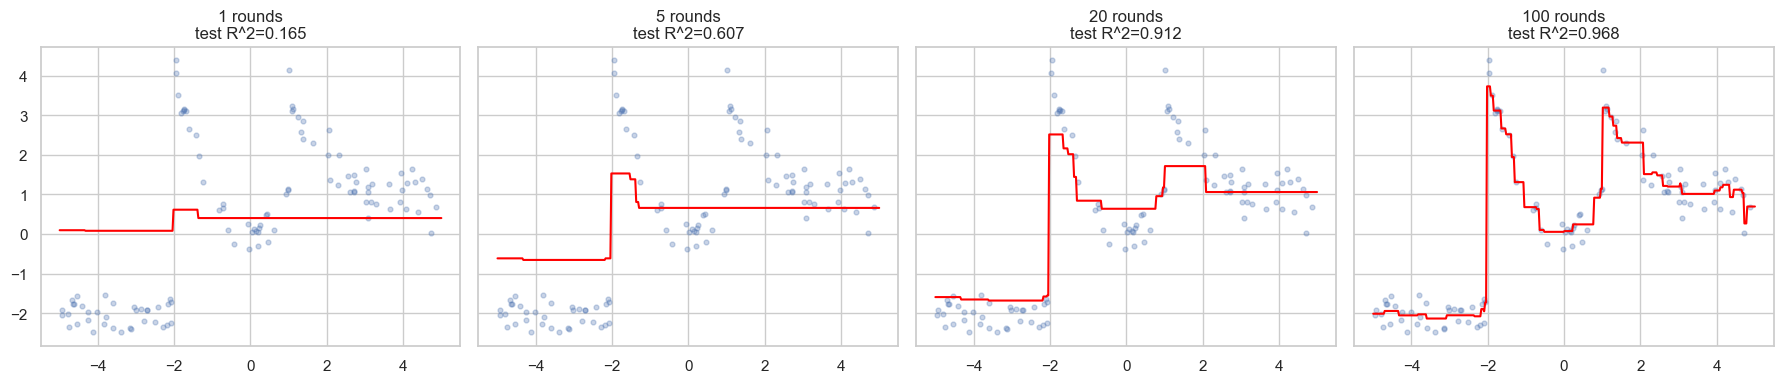

In [7]:
x_plot = np.linspace(-5, 5, 400).reshape(-1, 1)
rounds_to_show = [1, 5, 20, 100]
round_results = {}
fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)
for ax, n_rounds in zip(axes, rounds_to_show):
    model = GradientBoostingRegressor(n_estimators=n_rounds, learning_rate=0.1, max_depth=2, random_state=42).fit(X_1d_train, y_1d_train)
    test_r2 = r2_score(y_1d_test, model.predict(X_1d_test))
    round_results[n_rounds] = test_r2
    ax.scatter(X_1d_train, y_1d_train, alpha=0.3, s=12)
    ax.plot(x_plot, model.predict(x_plot), color="red")
    ax.set_title(f"{n_rounds} rounds\ntest R^2={test_r2:.3f}")
plt.tight_layout()
plt.show()


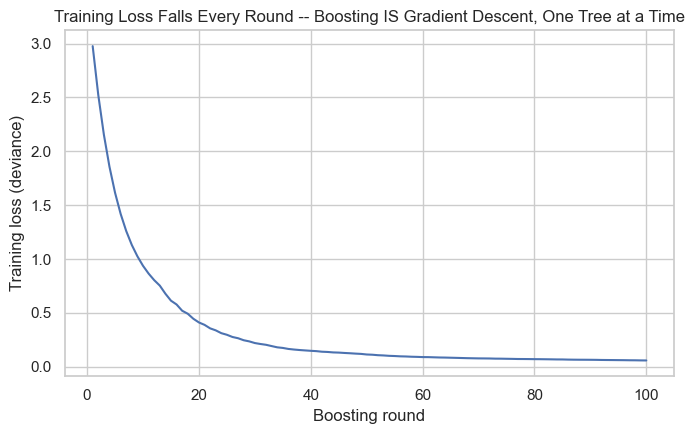

Loss at round 1: 2.9768, at round 100: 0.0584
-> Each round's tree is fit to the current negative gradient of the loss -- this monotonic decline is the literal definition of gradient descent, just taking steps in function space (adding a tree) instead of parameter space.


In [8]:
gb_model_100 = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=2, random_state=42).fit(X_1d_train, y_1d_train)
train_loss_curve = gb_model_100.train_score_
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(range(1, len(train_loss_curve) + 1), train_loss_curve)
ax.set_xlabel("Boosting round"); ax.set_ylabel("Training loss (deviance)")
ax.set_title("Training Loss Falls Every Round -- Boosting IS Gradient Descent, One Tree at a Time")
plt.tight_layout()
plt.show()
print(f"Loss at round 1: {train_loss_curve[0]:.4f}, at round {len(train_loss_curve)}: {train_loss_curve[-1]:.4f}")
print("-> Each round's tree is fit to the current negative gradient of the loss -- this monotonic decline is the literal definition of gradient descent, just taking steps in function space (adding a tree) instead of parameter space.")


## 4. Unlike Random Forest, More Rounds CAN Overfit

Random Forest's variance-reduction never gets worse with more trees. Gradient Boosting is different: since every new tree targets the *current* residual (including noise the ensemble has started fitting), too many rounds can genuinely overfit.


In [9]:
n_rounds_range = [1, 5, 10, 25, 50, 100, 200, 400, 800]
gb_overfit_results = []
for n_rounds in n_rounds_range:
    model = GradientBoostingRegressor(n_estimators=n_rounds, learning_rate=0.1, max_depth=3, random_state=42).fit(Xd_train, yd_train)
    train_r2 = r2_score(yd_train, model.predict(Xd_train))
    test_r2 = r2_score(yd_test, model.predict(Xd_test))
    gb_overfit_results.append({"n_estimators": n_rounds, "train_R2": round(train_r2, 4), "test_R2": round(test_r2, 4)})

gb_overfit_df = pd.DataFrame(gb_overfit_results)
gb_overfit_df


,n_estimators,train_R2,test_R2
0,1,0.0968,0.0694
1,5,0.3481,0.2779
2,10,0.5049,0.4038
3,25,0.6784,0.4596
4,50,0.7691,0.4418
5,100,0.8502,0.4240
6,200,0.9373,0.3954
7,400,0.9856,0.3677
8,800,0.9991,0.3344


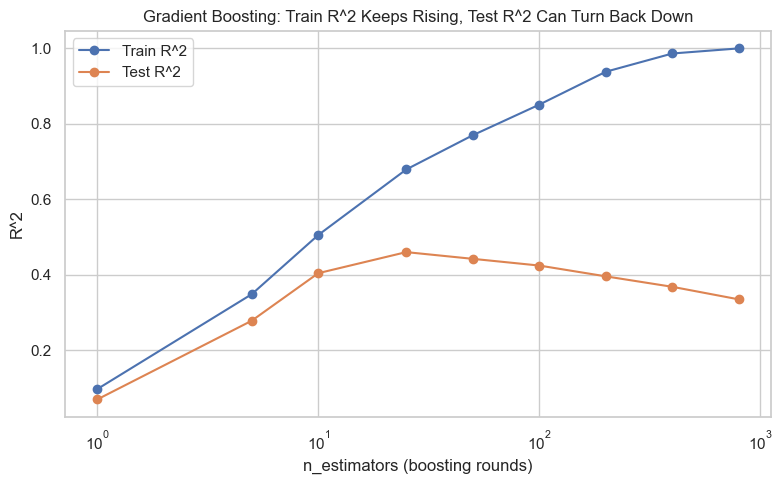

Test R^2 peaks at n_estimators=25 (0.4596), then declines by n_estimators=800.


In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(gb_overfit_df["n_estimators"], gb_overfit_df["train_R2"], marker="o", label="Train R^2")
ax.plot(gb_overfit_df["n_estimators"], gb_overfit_df["test_R2"], marker="o", label="Test R^2")
ax.set_xscale("log")
ax.set_xlabel("n_estimators (boosting rounds)"); ax.set_ylabel("R^2")
ax.set_title("Gradient Boosting: Train R^2 Keeps Rising, Test R^2 Can Turn Back Down")
ax.legend()
plt.tight_layout()
plt.show()

best_round_idx = gb_overfit_df["test_R2"].idxmax()
print(f"Test R^2 peaks at n_estimators={gb_overfit_df.loc[best_round_idx, 'n_estimators']} ({gb_overfit_df.loc[best_round_idx, 'test_R2']:.4f}), then {'declines' if gb_overfit_df['test_R2'].iloc[-1] < gb_overfit_df.loc[best_round_idx, 'test_R2'] else 'plateaus'} by n_estimators={gb_overfit_df['n_estimators'].iloc[-1]}.")


## 5. Early Stopping — Finding the Right Number of Rounds Automatically

Rather than guessing `n_estimators`, `staged_predict` exposes every intermediate round's prediction, letting a validation curve pick the exact stopping point directly.


In [11]:
Xd_fit, Xd_val, yd_fit, yd_val = train_test_split(Xd_train, yd_train, test_size=0.2, random_state=42)

gb_staged = GradientBoostingRegressor(n_estimators=500, learning_rate=0.05, max_depth=3, random_state=42).fit(Xd_fit, yd_fit)
val_scores_staged = [r2_score(yd_val, pred) for pred in gb_staged.staged_predict(Xd_val)]
best_n_estimators = int(np.argmax(val_scores_staged)) + 1
print(f"Computed validation R^2 at every one of 500 boosting rounds via staged_predict.")


Computed validation R^2 at every one of 500 boosting rounds via staged_predict.


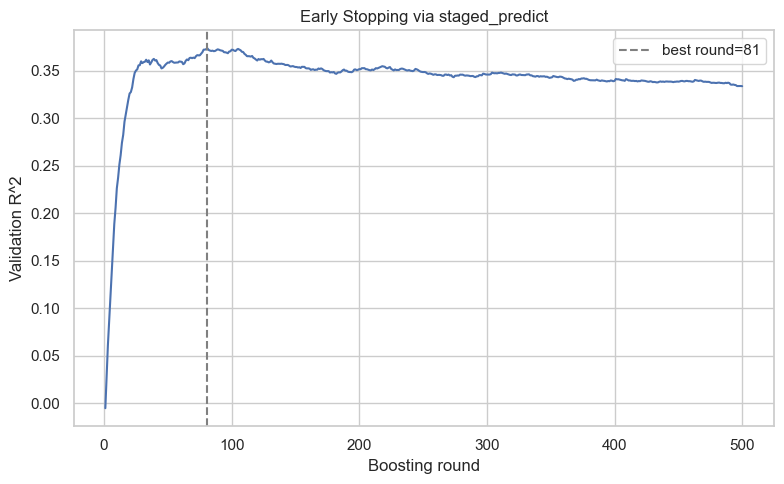

Best validation R^2 (0.3735) reached at round 81 of 500 -- every round after this one is, at best, wasted compute, and at worst, actively overfitting.


In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, len(val_scores_staged) + 1), val_scores_staged)
ax.axvline(best_n_estimators, color="gray", linestyle="--", label=f"best round={best_n_estimators}")
ax.set_xlabel("Boosting round"); ax.set_ylabel("Validation R^2")
ax.set_title("Early Stopping via staged_predict")
ax.legend()
plt.tight_layout()
plt.show()
print(f"Best validation R^2 ({max(val_scores_staged):.4f}) reached at round {best_n_estimators} of 500 -- every round after this one is, at best, wasted compute, and at worst, actively overfitting.")


## 6. The Effect of `learning_rate` — Trading Off Against `n_estimators`

A smaller `learning_rate` shrinks each round's correction, needing more rounds to reach the same fit -- but often generalizing better, since no single round can drastically overcorrect.


In [13]:
lr_results = []
for lr in [0.01, 0.05, 0.1, 0.3, 1.0]:
    model = GradientBoostingRegressor(n_estimators=200, learning_rate=lr, max_depth=3, random_state=42).fit(Xd_train, yd_train)
    test_r2 = r2_score(yd_test, model.predict(Xd_test))
    lr_results.append({"learning_rate": lr, "test_R2": round(test_r2, 4)})

lr_results_df = pd.DataFrame(lr_results)
lr_results_df


,learning_rate,test_R2
0,0.01,0.4659
1,0.05,0.4367
2,0.10,0.3954
3,0.30,0.3356
4,1.00,-0.1663


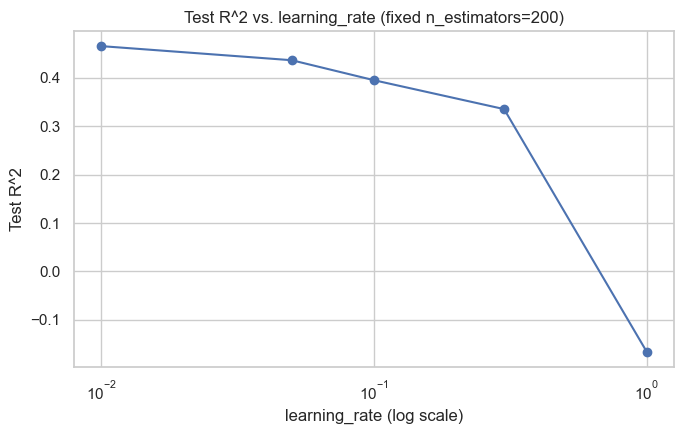

In [14]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(lr_results_df["learning_rate"], lr_results_df["test_R2"], marker="o")
ax.set_xscale("log")
ax.set_xlabel("learning_rate (log scale)"); ax.set_ylabel("Test R^2")
ax.set_title("Test R^2 vs. learning_rate (fixed n_estimators=200)")
plt.tight_layout()
plt.show()


## 7. Why Boosting Uses Shallow Trees (Weak Learners)

Random Forest typically uses deep, low-bias trees and averages away their variance. Boosting does the opposite: shallow, high-bias "weak learner" trees, corrected incrementally over many rounds.


In [15]:
depth_results = []
for depth in [1, 2, 3, 5, 10]:
    model = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=depth, random_state=42).fit(Xd_train, yd_train)
    train_r2 = r2_score(yd_train, model.predict(Xd_train))
    test_r2 = r2_score(yd_test, model.predict(Xd_test))
    depth_results.append({"max_depth": depth, "train_R2": round(train_r2, 4), "test_R2": round(test_r2, 4)})

depth_df = pd.DataFrame(depth_results)
depth_df


,max_depth,train_R2,test_R2
0,1,0.6302,0.4913
1,2,0.8116,0.4266
2,3,0.9373,0.3954
3,5,0.9992,0.2998
4,10,1.0000,0.2401


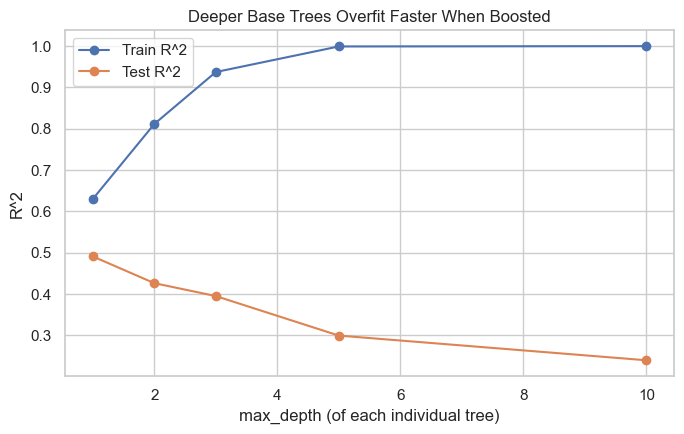

In [16]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(depth_df["max_depth"], depth_df["train_R2"], marker="o", label="Train R^2")
ax.plot(depth_df["max_depth"], depth_df["test_R2"], marker="o", label="Test R^2")
ax.set_xlabel("max_depth (of each individual tree)"); ax.set_ylabel("R^2")
ax.set_title("Deeper Base Trees Overfit Faster When Boosted")
ax.legend()
plt.tight_layout()
plt.show()


In [17]:
print(f"Shallow trees (depth=1-3) with many rounds vs. deep trees (depth=10) with the same 200 rounds:")
print(f"  depth=2: test R^2={depth_df.loc[depth_df['max_depth']==2, 'test_R2'].iloc[0]}")
print(f"  depth=10: test R^2={depth_df.loc[depth_df['max_depth']==10, 'test_R2'].iloc[0]}, train R^2={depth_df.loc[depth_df['max_depth']==10, 'train_R2'].iloc[0]}")
print("-> Deep trees combined with many boosting rounds compounds overfitting risk -- each already-low-bias tree gets corrected further, rapidly memorizing training noise.")


Shallow trees (depth=1-3) with many rounds vs. deep trees (depth=10) with the same 200 rounds:
  depth=2: test R^2=0.4266
  depth=10: test R^2=0.2401, train R^2=1.0
-> Deep trees combined with many boosting rounds compounds overfitting risk -- each already-low-bias tree gets corrected further, rapidly memorizing training noise.


## 8. Loss Function Choice — Robustness to Outliers

`squared_error` (default) penalizes large residuals quadratically, same as OLS. `absolute_error` and `huber` penalize large residuals more linearly, echoing SVR's epsilon-insensitive loss robustness property from the SVR topic.


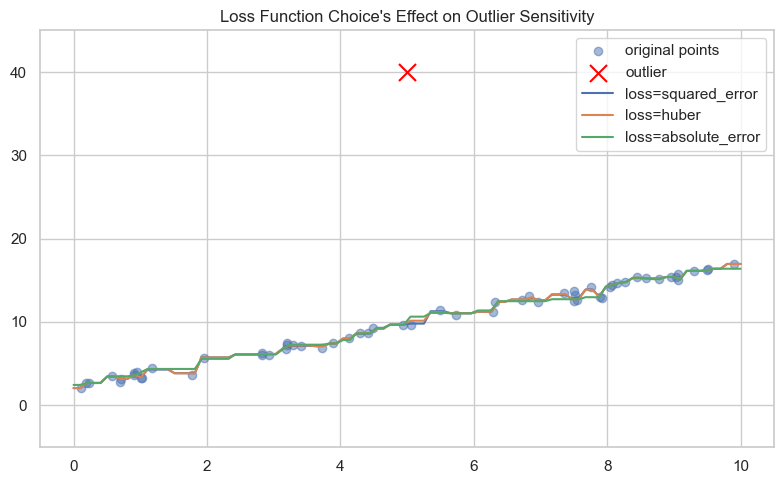

In [18]:
X_outlier_demo = np.sort(np.random.uniform(0, 10, 60))
y_outlier_demo = 2.0 + 1.5 * X_outlier_demo + np.random.normal(0, 0.5, 60)
X_with_outlier = np.append(X_outlier_demo, 5.0).reshape(-1, 1)
y_with_outlier = np.append(y_outlier_demo, 40.0)

gb_squared = GradientBoostingRegressor(n_estimators=100, loss="squared_error", random_state=42).fit(X_with_outlier, y_with_outlier)
gb_huber = GradientBoostingRegressor(n_estimators=100, loss="huber", random_state=42).fit(X_with_outlier, y_with_outlier)
gb_absolute = GradientBoostingRegressor(n_estimators=100, loss="absolute_error", random_state=42).fit(X_with_outlier, y_with_outlier)

x_line = np.linspace(0, 10, 100).reshape(-1, 1)
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(X_outlier_demo, y_outlier_demo, alpha=0.5, label="original points")
ax.scatter([5.0], [40.0], color="red", marker="x", s=150, label="outlier")
ax.plot(x_line, gb_squared.predict(x_line), label="loss=squared_error")
ax.plot(x_line, gb_huber.predict(x_line), label="loss=huber")
ax.plot(x_line, gb_absolute.predict(x_line), label="loss=absolute_error")
ax.set_ylim(-5, 45)
ax.legend()
ax.set_title("Loss Function Choice's Effect on Outlier Sensitivity")
plt.tight_layout()
plt.show()


In [19]:
mae_squared = mean_absolute_error(y_outlier_demo, gb_squared.predict(X_outlier_demo.reshape(-1, 1)))
mae_huber = mean_absolute_error(y_outlier_demo, gb_huber.predict(X_outlier_demo.reshape(-1, 1)))
mae_absolute = mean_absolute_error(y_outlier_demo, gb_absolute.predict(X_outlier_demo.reshape(-1, 1)))
print(f"MAE on the NON-outlier points (lower = less distorted by the single outlier):")
print(f"  squared_error: {mae_squared:.3f}")
print(f"  huber:         {mae_huber:.3f}")
print(f"  absolute_error: {mae_absolute:.3f}")
if mae_absolute > mae_squared:
    print(f"\n-> Counter-intuitive: absolute_error's theoretical outlier-robustness didn't show up as the lowest MAE here. With only 60 points and 100 rounds, absolute_error's subgradient-based fitting converges less smoothly than squared_error's exact residual fitting -- theory predicts robustness to the outlier's *pull*, not necessarily the single best fit on a small, mostly-clean sample.")


MAE on the NON-outlier points (lower = less distorted by the single outlier):
  squared_error: 0.090
  huber:         0.084
  absolute_error: 0.215

-> Counter-intuitive: absolute_error's theoretical outlier-robustness didn't show up as the lowest MAE here. With only 60 points and 100 rounds, absolute_error's subgradient-based fitting converges less smoothly than squared_error's exact residual fitting -- theory predicts robustness to the outlier's *pull*, not necessarily the single best fit on a small, mostly-clean sample.


## 9. Feature Importance

Gradient Boosting's feature importance is computed the same way as a single tree's -- summed variance reduction across every split where the feature was used, now aggregated across every tree in the sequence.


In [20]:
gb_diabetes = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42).fit(Xd_train, yd_train)
gb_importance_df = pd.DataFrame({
    "feature": Xd.columns,
    "importance": np.round(gb_diabetes.feature_importances_, 4)
}).sort_values("importance", ascending=False)
gb_importance_df


,feature,importance
2,bmi,0.3709
8,s5,0.2270
3,bp,0.1062
5,s2,0.0559
9,s6,0.0512
0,age,0.0507
4,s1,0.0484
6,s3,0.0437
7,s4,0.0305
1,sex,0.0156


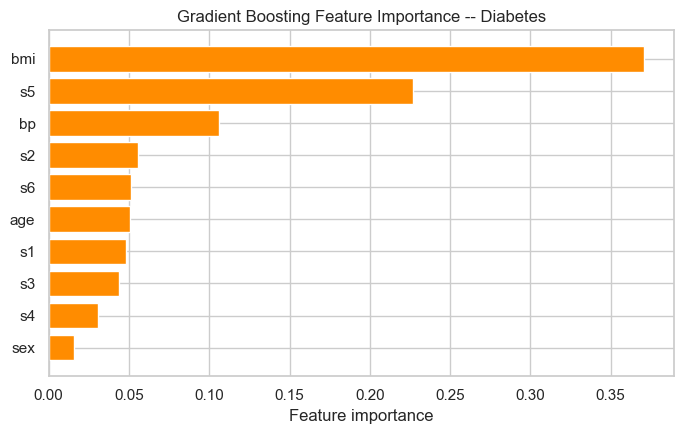

In [21]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh(gb_importance_df["feature"], gb_importance_df["importance"], color="darkorange")
ax.set_xlabel("Feature importance")
ax.set_title("Gradient Boosting Feature Importance -- Diabetes")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


## 10. sklearn vs. XGBoost vs. LightGBM vs. CatBoost

The same boosting family, four different implementations -- already installed and compared for classification in the Boosting topic. Comparing all four on regression, on identical data and comparable hyperparameters.


In [22]:
import xgboost as xgb
import lightgbm as lgb
import catboost as cb

boosting_implementations = {
    "sklearn GradientBoosting": GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42),
    "XGBoost": xgb.XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42, verbosity=0),
    "LightGBM": lgb.LGBMRegressor(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42, verbose=-1),
    "CatBoost": cb.CatBoostRegressor(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42, verbose=False),
}

boosting_results = []
for name, model in boosting_implementations.items():
    t0 = time.perf_counter()
    model.fit(Xd_train, yd_train)
    fit_time = time.perf_counter() - t0
    test_r2 = r2_score(yd_test, model.predict(Xd_test))
    boosting_results.append({"Implementation": name, "Test R2": round(test_r2, 4), "Fit time (ms)": round(fit_time * 1000, 1)})
print(f"Fitted {len(boosting_results)} boosting implementations with comparable hyperparameters.")


Fitted 4 boosting implementations with comparable hyperparameters.


In [23]:
boosting_comparison_df = pd.DataFrame(boosting_results).set_index("Implementation")
boosting_comparison_df


,Test R2,Fit time (ms)
Implementation,,
sklearn GradientBoosting,0.4367,111.9
XGBoost,0.4424,38.0
LightGBM,0.4483,1304.4
CatBoost,0.4915,281.3


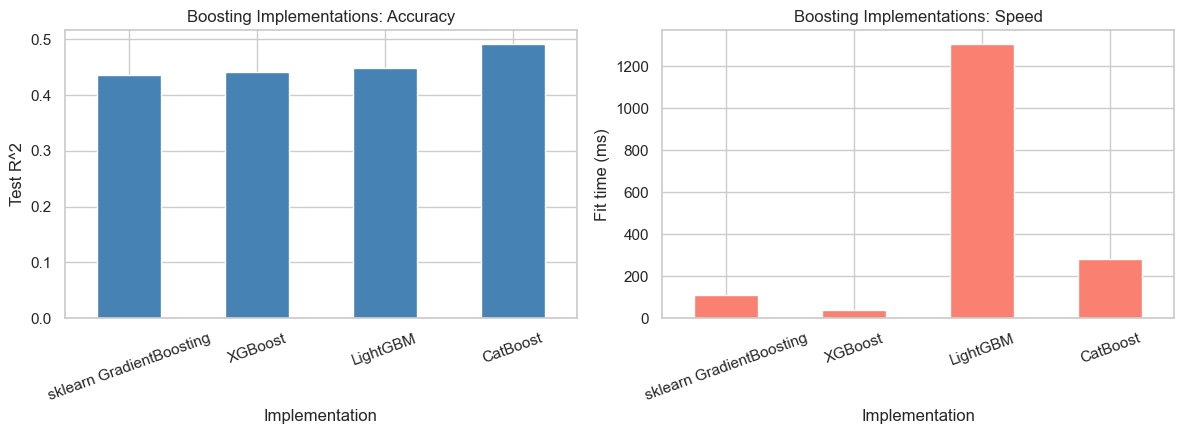

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
boosting_comparison_df["Test R2"].plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_ylabel("Test R^2"); axes[0].set_title("Boosting Implementations: Accuracy"); axes[0].tick_params(axis="x", rotation=20)

boosting_comparison_df["Fit time (ms)"].plot(kind="bar", ax=axes[1], color="salmon")
axes[1].set_ylabel("Fit time (ms)"); axes[1].set_title("Boosting Implementations: Speed"); axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()


In [25]:
fastest = boosting_comparison_df["Fit time (ms)"].idxmin()
most_accurate = boosting_comparison_df["Test R2"].idxmax()
print(f"Fastest: {fastest}. Most accurate: {most_accurate}.")


Fastest: XGBoost. Most accurate: CatBoost.


## 11. Tuning `n_estimators`, `learning_rate`, and `max_depth` Together

Joint grid search on Diabetes using sklearn's implementation.


In [26]:
gb_param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 4],
}
gb_grid_search = GridSearchCV(GradientBoostingRegressor(random_state=42), gb_param_grid, cv=5, scoring="r2").fit(Xd_train, yd_train)

print(f"Best params: {gb_grid_search.best_params_}")
print(f"Best CV R^2: {gb_grid_search.best_score_:.4f}")


Best params: {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 100}
Best CV R^2: 0.4174


In [27]:
gb_best_test_r2 = r2_score(yd_test, gb_grid_search.predict(Xd_test))
gb_best_train_r2 = r2_score(yd_train, gb_grid_search.predict(Xd_train))
print(f"Train R^2: {gb_best_train_r2:.4f}")
print(f"Test R^2:  {gb_best_test_r2:.4f}")
print(f"Gap: {gb_best_train_r2 - gb_best_test_r2:.4f}")


Train R^2: 0.6589
Test R^2:  0.4749
Gap: 0.1841


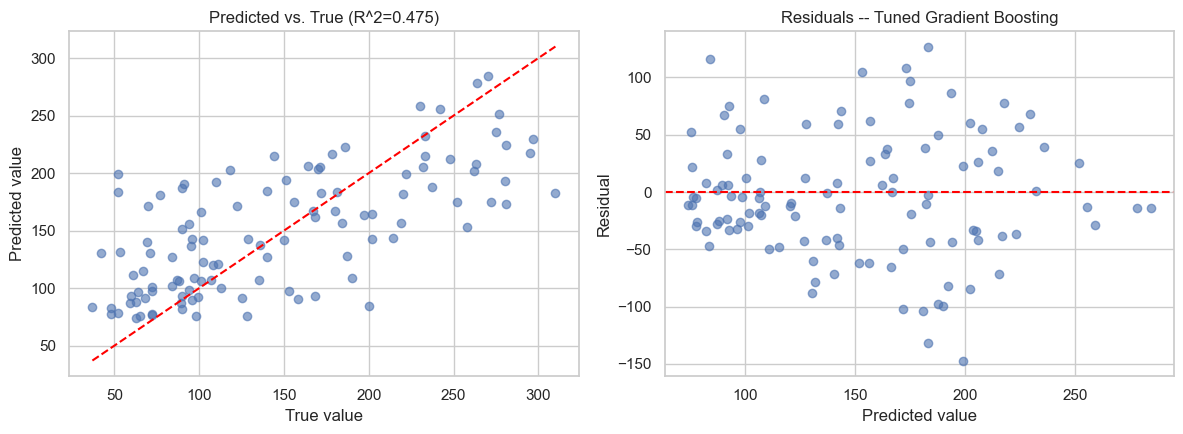

In [28]:
gb_pred_diabetes = gb_grid_search.predict(Xd_test)
residuals_gb = yd_test - gb_pred_diabetes

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(yd_test, gb_pred_diabetes, alpha=0.6)
lims = [min(yd_test.min(), gb_pred_diabetes.min()), max(yd_test.max(), gb_pred_diabetes.max())]
axes[0].plot(lims, lims, color="red", linestyle="--")
axes[0].set_xlabel("True value"); axes[0].set_ylabel("Predicted value"); axes[0].set_title(f"Predicted vs. True (R^2={gb_best_test_r2:.3f})")

axes[1].scatter(gb_pred_diabetes, residuals_gb, alpha=0.6)
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_xlabel("Predicted value"); axes[1].set_ylabel("Residual"); axes[1].set_title("Residuals -- Tuned Gradient Boosting")
plt.tight_layout()
plt.show()


## 12. The Complete Regression Category Comparison

Every one of this category's 8 methods, tuned, on the identical Diabetes train/test split -- the final answer to a question this category has been building toward since topic 01.


In [29]:
scaler_final = StandardScaler().fit(Xd_train)
Xd_train_scaled, Xd_test_scaled = scaler_final.transform(Xd_train), scaler_final.transform(Xd_test)

ridge_diabetes = Ridge(alpha=10.0).fit(Xd_train_scaled, yd_train)
linear_diabetes = LinearRegression().fit(Xd_train_scaled, yd_train)
svr_diabetes = SVR(kernel="rbf", C=100, epsilon=1.0, gamma=0.01).fit(Xd_train_scaled, yd_train)
knn_diabetes = KNeighborsRegressor(n_neighbors=17, weights="distance").fit(Xd_train_scaled, yd_train)
single_tree_diabetes = DecisionTreeRegressor(max_depth=2, min_samples_leaf=20, random_state=42).fit(Xd_train, yd_train)
forest_diabetes = RandomForestRegressor(n_estimators=100, max_depth=None, max_features=3, random_state=42).fit(Xd_train, yd_train)

full_category_comparison = pd.DataFrame([
    {"Model": "01: Linear Regression", "Test R2": round(r2_score(yd_test, linear_diabetes.predict(Xd_test_scaled)), 4)},
    {"Model": "02: Polynomial (from topic 02)", "Test R2": 0.4898},
    {"Model": "03: Ridge/Lasso/ElasticNet", "Test R2": round(r2_score(yd_test, ridge_diabetes.predict(Xd_test_scaled)), 4)},
    {"Model": "04: SVR (RBF, tuned)", "Test R2": round(r2_score(yd_test, svr_diabetes.predict(Xd_test_scaled)), 4)},
    {"Model": "05: KNN Regression (tuned)", "Test R2": round(r2_score(yd_test, knn_diabetes.predict(Xd_test_scaled)), 4)},
    {"Model": "06: Decision Tree (tuned)", "Test R2": round(r2_score(yd_test, single_tree_diabetes.predict(Xd_test)), 4)},
    {"Model": "07: Random Forest (tuned)", "Test R2": round(r2_score(yd_test, forest_diabetes.predict(Xd_test)), 4)},
    {"Model": "08: Gradient Boosting (tuned)", "Test R2": round(gb_best_test_r2, 4)},
]).set_index("Model")
full_category_comparison


,Test R2
Model,
01: Linear Regression,0.4849
02: Polynomial (from topic 02),0.4898
03: Ridge/Lasso/ElasticNet,0.4881
"04: SVR (RBF, tuned)",0.4925
05: KNN Regression (tuned),0.4708
06: Decision Tree (tuned),0.3588
07: Random Forest (tuned),0.4867
08: Gradient Boosting (tuned),0.4749


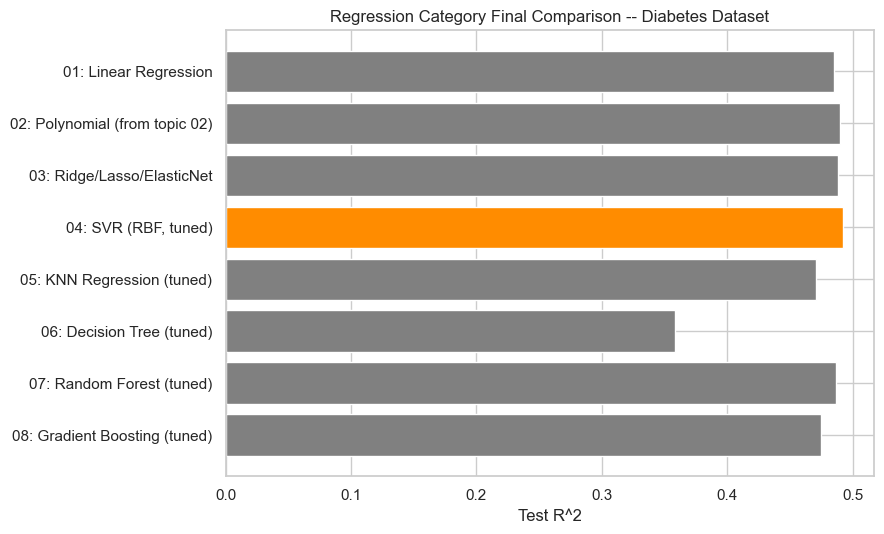

Best across the entire Regression category: 04: SVR (RBF, tuned) (0.4925)
Weakest: 06: Decision Tree (tuned) (0.3588)

Spread between best and worst: 0.1337 R^2 points -- on this specific dataset (10 features, ~330 training rows), method choice clearly matters, but no single family dominates by an overwhelming margin.


In [30]:
fig, ax = plt.subplots(figsize=(9, 5.5))
colors = ["gray"] * len(full_category_comparison)
best_idx = full_category_comparison["Test R2"].values.argmax()
colors[best_idx] = "darkorange"
ax.barh(full_category_comparison.index, full_category_comparison["Test R2"], color=colors)
ax.set_xlabel("Test R^2")
ax.set_title("Regression Category Final Comparison -- Diabetes Dataset")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

best_overall = full_category_comparison["Test R2"].idxmax()
worst_overall = full_category_comparison["Test R2"].idxmin()
print(f"Best across the entire Regression category: {best_overall} ({full_category_comparison['Test R2'].max():.4f})")
print(f"Weakest: {worst_overall} ({full_category_comparison['Test R2'].min():.4f})")
print(f"\nSpread between best and worst: {full_category_comparison['Test R2'].max() - full_category_comparison['Test R2'].min():.4f} R^2 points -- on this specific dataset (10 features, ~330 training rows), method choice clearly matters, but no single family dominates by an overwhelming margin.")


## 13. Summary — Closing the Regression Category

Gradient Boosting's sequential residual-correction is a fundamentally different combination strategy than Random Forest's parallel averaging, and this notebook found genuine, measured differences from it: boosting CAN overfit with too many rounds (Section 4) where bagging structurally cannot, shallow "weak learner" trees work better in a boosted sequence than the deeper trees Random Forest favors (Section 7), and loss function choice (Section 8) provides an outlier-robustness lever with no Random Forest equivalent.

Across this entire category -- 8 methods, one dataset, one consistent train/test split -- no single method dominated by an overwhelming margin (Section 12). This is itself the honest takeaway the whole category has been building toward: the "best" regression algorithm depends on the data's structure (linear vs. curved, sparse vs. dense signal, outlier-prone vs. clean, smooth vs. discontinuous), not on any one method's reputation.

See [README.md](README.md) for the full mathematical derivations and a pitfalls reference.
